# bert-1
- run pipeline

In [ ]:
from nlp import ClimateBERTAnalyzer, analyze_reports

stats = analyze_reports('../data/reports/Baosteel')
# stats = analyze_reports("../data/reports")

# bert-2
- run vizualisations

In [4]:
from nlp import ClimateBERTVisualizer, visualize_results

visualize_results("../cache", "../out")

✅ Loaded: 193 reports, 15 companies, 2013-2024

EXPORTING CSV FILES
   ✓ company_year.csv (129 rows)
   ✓ company_totals.csv (15 companies)
   ✓ yearly_industry.csv (12 years)
   ✓ funnel_company_year.csv (129 rows)

   📁 All CSVs saved to: ../out/

GENERATING PLOTS
   ✓ slide_main.png
   ✓ slide_sentiment_trend.png
   ✓ talk_score_trend.png
   ✓ funnel_trend.png
   ✓ talk_score_per_company.png
   ✓ per_company_components.png
   ✓ per_company_sentiment.png
   ✓ sentiment_all_companies.png
   ✓ n0_funnel.png
   ✓ n0_quality_comparison.png
   ✓ n0_per_company.png
   ✓ n0_gap_analysis.png

   📁 All plots saved to: ../out/

   Generating word frequency plots...

   📊 ALL CHUNKS (top 30):
   environment(17950), sustainable(17493), production(16608), emission(14006), management(13797), energy(12048), financial(11688), development(11410), business(11035), reduction(10864), products(9790), million(9437), carbon(9152), iron(8384), process(6902)

   🌱 OPPORTUNITY chunks (top 15):
   production(7

# rag

## Reload modules

run when changing code in .py file

In [ ]:
%load_ext autoreload
%autoreload 2
# %aimport nlp.rag

# if still didnt reload changes do 'restart kernel' / restart vscode

## Model Testing

Test which models work for extraction (format compliance + quality).

In [ ]:
from nlp.test import save_test_results
from nlp.test import test_models, compare_extractions
from nlp import Config

# Available models (for reference):
# Groq:   mixtral-8x7b-32768, gemma2-9b-it
# Ollama: gemma3:4b

MODELS = [
    # Groq (free tier: 6k TPM - use small batch_size)
    # Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3),
    # Config(llm_provider="groq", model="llama-3.3-70b-versatile", approach="exhaustive", ctx=128000, batch_size=5),

    # RAG approach
    Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=False),

    # Ollama
    # Tested: gemma3:4b ctx=4096 works but slow (108s), qwen2.5:3b fails format
    # Config(llm_provider="ollama", model="qwen2.5:3b", approach="exhaustive", ctx=4096),  # 1.9GB - FAIL format
    # Config(llm_provider="ollama", model="gemma3:4b", approach="exhaustive", ctx=4096),   # 3.3GB - PASS but slow

    # Testing: smaller ctx to reduce VRAM pressure on 4GB GPU
    # Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096),  # 2.0GB
    # Config(llm_provider="ollama", model="llama3.1:8b ", approach="exhaustive", ctx=4096),  # 2.0GB

    # Config(llm_provider="ollama", model="qwen3:4b", approach="exhaustive", ctx=2048),     # 2.5GB
]

results = test_models(MODELS, skip_extraction=False)
compare_extractions(results)
save_test_results(results) # Save test results (same format as full pipeline: CSV + stats.json with prompts)

MODEL TESTING (1 models) - 006/2023

--- groq/llama-3.1-8b-instant [rag, top_k=20] (ctx=128,000 → 72 chunks) ---
    ERROR: Error code: 503 - {'error': {'message': 'llama-3.1-8b-instant is currently over capacity. Please try again and back off exponentially. Visit https://groqstatus.com to see if there is an active incident.', 'type': 'internal_server_error'}}

Model                                    Approach     Fmt    Time    B     M     Chunks
----------------------------------------------------------------------
groq/llama-3.1-8b-instant                             ERROR
Need 2+ models with extraction results to compare


## Run Extraction

Configure and run the full extraction pipeline.

In [3]:
from nlp import load_pipeline, Config

# Exhaustive (all chunks batched through LLM)
# config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3)
# config = Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096)

config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=True)

pipeline = load_pipeline(config)
pipeline.print_chunk_overview()

✓ Pipeline initialized (GPU: NVIDIA T1200 Laptop GPU (3.9GB))
✓ Loaded 15593 chunks from 15 companies (../cache)
Loading FAISS index from ../cache/faiss_index
Loading embedding model: Snowflake/snowflake-arctic-embed-s
✓ FAISS index loaded (15593 vectors)

CHUNK DISTRIBUTION (Years × Companies)
Year      ArcelorMit..    Acerinox    Outokumpu    Salzgitter     SSAB    TataSteelN..    Celsa    Voestalpine    Acciaierie..    TataSteelUK    Dillinger    SIDENOR    Feralpi    NipponSteel    Baosteel    TOTAL
                 (001)       (002)        (003)         (004)    (005)           (006)    (007)          (008)           (009)          (010)        (012)      (013)      (014)          (015)       (016)
------  --------------  ----------  -----------  ------------  -------  --------------  -------  -------------  --------------  -------------  -----------  ---------  ---------  -------------  ----------  -------
2013               320           0          111            52       49    

In [4]:
results = pipeline.extract_all_companies(resume=True)


EXTRACTION RUN
  LLM: groq/llama-3.1-8b-instant
  Context: 128,000 tokens → 72 chunks/batch
  Chunks: 15593 (1750 avg chars, 38-19629 range)
  Groups: 132 | Est. LLM calls: 568
  Resuming: 13 companies skipped (CSVs exist), 2 remaining


Extracting: AcciaieriedItalia (009)
Years: ['2021', '2022']
Retrieval: top_k=20, strategy=mmr


  009:   0%|          | 0/2 [00:00<?, ?it/s]

Loading Groq: llama-3.1-8b-instant


    B done: 5 found in 1 batches (0.5s)          
  ✓ Extracted 5 barriers, 0 motivators

Extracting: TataSteelUK (010)
Years: ['2021', '2022', '2023', '2024']
Retrieval: top_k=20, strategy=mmr


  ✓ Extracted 0 barriers, 0 motivators

✓ EXTRACTION COMPLETE
  Time: 1.0s (0.0min)
  Results: 1698 barriers, 1255 motivators
  Resumed: 13 companies from cache
  Saved: ../out/stats.json



In [ ]:
# Display results for a specific company
# company_id = "001"  # pick from results.keys()
# df_barriers, df_motivators = results[company_id]
# pipeline.display_results(company_id, df_barriers, df_motivators)

# topic modelling

📁 Run: run_04 → ../out/topics/run_04

📂 LOADING DATA

📂 Loading 15 CSV files from ../out...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 902.66it/s]


⚠️  Error loading barriers_010.csv: No columns to parse from file
✅ Loaded 1698 rows from 14 files

📂 Loading 15 CSV files from ../out...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 837.42it/s]

⚠️  Error loading motivators_010.csv: No columns to parse from file
⚠️  Error loading motivators_009.csv: No columns to parse from file
✅ Loaded 1255 rows from 13 files

🎯 TOPIC MODELING: BARRIERS
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
📂 Loaded cached embeddings from ../out/topics/embeddings_barriers.npy

🔄 Processing 1698 documents from 'barriers'...

🔧 Creating BERTopic model components...
  📐 UMAP: 15D, n_neighbors=30
  🎯 HDBSCAN: min_cluster_size=8, min_samples=1
  🔑 Using KeyBERTInspired + MMR (diversity=0.4)

🤖 Loading embedding model: Snowflake/snowflake-arctic-embed-s


...


✅ Found 46 topics
   📍 212 documents classified as outliers (topic -1)
💾 Cached embeddings to ../out/topics/embeddings_motivators.npy
✅ Saved model to ../out/topics/run_04/motivators_model
✅ Saved embeddings to ../out/topics/run_04/motivators_embeddings.npy

🔄 Reducing 212 outliers using 'embeddings' strategy...
✅ Reassigned 212 outliers to topics

📋 Topic Summary:
------------------------------------------------------------
Topic -1:  212 docs | practices, practices opportunity, sustainable practices, principles, issues
Topic 0:  140 docs | potential steel, solutions, demand high, increased, increasing
Topic 1:   78 docs | neutrality developed, neutrality contribution, neutrality increasing, possible, solution
Topic 2:   65 docs | impacts opportunities, analysis, effects, follow, change mitigation
Topic 3:   44 docs | value, importance, principles, commitment, development commitment
Topic 4:   43 docs | research, introduction, develop new, development new, developing new
Topic 5:   4

13it [00:09,  1.39it/s]


  ✓ motivators_over_time.html


13it [00:08,  1.60it/s]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png
  ✓ Saved motivators_company_year.csv

✅ PIPELINE COMPLETE
📁 Results saved to: ../out/topics/run_04
⏱️  Duration: 352.8s
📊 Outliers: barriers 198/1698 (11.7%), motivators 212/1255 (16.9%)
📝 Config logged to ../out/topics/run_04/config_log.txt


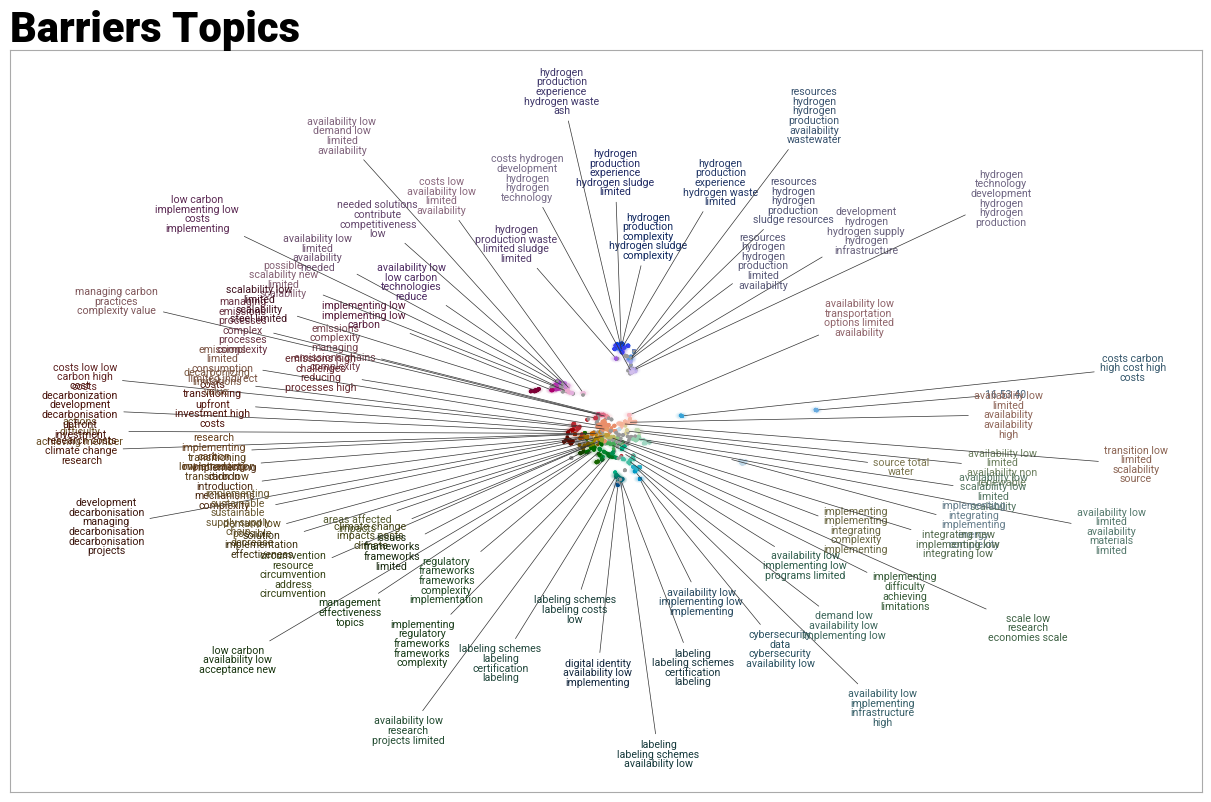

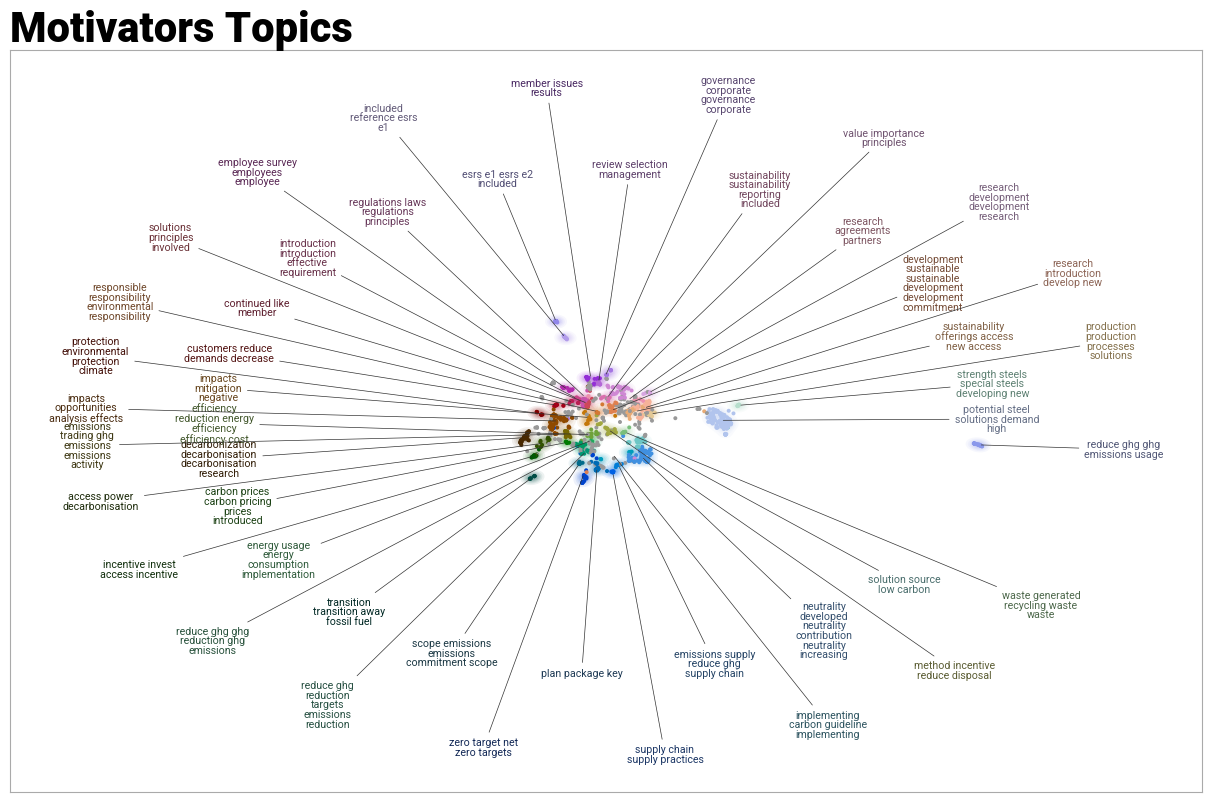

In [2]:
from nlp import TopicModelConfig, run_topic_modeling_pipeline


config = TopicModelConfig(
    # Embedding model
    embedding_model="Snowflake/snowflake-arctic-embed-s",
    # embedding_model="sentence-transformers/all-mpnet-base-v2"
    # embedding_model="Octen/Octen-Embedding-4B"
    # embedding_model="BAAI/bge-small-en-v1.5", # ⚡/384d
    batch_size=64,
    cache_embeddings=True,  # cache to out/topics/embeddings_{category}.npy

    # Misc
    verbose=True,
    run_name="run", # auto-increments: run_01, run_02, ... (change base to e.g. "test_leaf")

    # UMAP (dimensionality reduction)
    umap_n_neighbors=30,
    umap_n_components=15,
    umap_min_dist=0.05,
    umap_metric='cosine',
    umap_random_state=42,

    # HDBSCAN (clustering)
    hdbscan_min_cluster_size=8,   # was 10 — lower = fewer outliers
    hdbscan_min_samples=1,        # was 2 — less conservative
    hdbscan_metric='euclidean',
    hdbscan_cluster_selection_method='eom',  # was 'leaf' — eom gives more natural cluster sizes

    # Vectorizer (c-TF-IDF)
    vectorizer_ngram_range=(1, 2),
    vectorizer_min_df=2,
    vectorizer_max_df=0.92,

    # Topic representation
    mmr_diversity=0.4, # 0=pure relevance, 1=max diversity
    top_n_words=10,
    nr_topics=None,  # was 10 — let HDBSCAN find natural clusters, merge manually if needed
    calculate_probabilities=True,

    # Outlier reduction (post-hoc)
    reduce_outliers=True,  # was False — reassign outliers to nearest topic
    reduce_outliers_strategy='embeddings',  # 'embeddings', 'c-tf-idf', or 'distributions'

    # Visualization UMAP (separate 2D projection)
    viz_umap_n_neighbors=10,
    viz_umap_n_components=2,
    viz_umap_min_dist=0.0,

    # LLM for topic labeling
    llm_provider="groq",  # "ollama" or "groq"
    model="llama-3.1-8b-instant",
    llm_temperature=0.0,
)

results = run_topic_modeling_pipeline(
    data_folder="../out",
    output_folder="../out/topics",
    config=config,
)
# Access results
barriers_df = results['barriers']['df']
motivators_df = results['motivators']['df']